# **Advanced Network Anomaly Detection Using Gradient Boosting and Time-Aware Features**

# 1. Introduction


Network anomalies can indicate cybersecurity threats such as intrusions, DDoS attacks, or abnormal traffic behavior. The goal of this project is to build machine learning models capable of detecting anomalous network activity using statistical and time-aware features.

# 2. Dataset Description

Network Anomality Dataset - Kaggle
Source: https://www.kaggle.com/datasets/amineipad/network-anoamly-dataset/data

The dataset contains 1,654 records with five columns: inbound rate, outbound rate, inbound bandwidth utilization, outbound bandwidth utilization, and a binary label indicating normal or anomalous activity. It is designed for binary classification problems in network anomaly detection, enabling researchers and practitioners to train and evaluate machine learning models that identify unusual traffic patterns. The features reflect quantitative network performance indicators, making the dataset suitable for cybersecurity analysis, intrusion detection experiments, and performance monitoring research.

The dataset includes features such as:
- Connection duration
- Protocol type
- Source bytes
- Destination bytes
- Service type
- Connection status flag

# 3. Data Cleaning & Preprocessing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
networks = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/networkanomalydataset.csv")

# Data cleaning (Checking missing values)
print("Missing values per column:")
networks.isnull().sum()

# Fill missing values (handling missing values)
for col in networks.select_dtypes(include=np.number).columns:
    networks[col] = networks[col].fillna(networks[col].median())

# Checking taget distribution (label values and class imbalance)
print("\nClass count:")
print(networks["Label"].value_counts())

# Class proportion shows the balance of normal vs. anomalous data
print("\nClass proportion:")
print(networks["Label"].value_counts(normalize=True))

# Brief Display of Dataset
print("\nDataset shape:")
print(networks.shape)

print("\nDataset info:")
networks.info()

print("\nStatistical summary:")
print(networks.describe())

print("\nPreview first rows:")
print(networks.head())

Missing values per column:

Class count:
Label
0    827
1    827
Name: count, dtype: int64

Class proportion:
Label
0    0.5
1    0.5
Name: proportion, dtype: float64

Dataset shape:
(1654, 5)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Inbound Rate(bit/s)                1654 non-null   float64
 1   Outbound Rate(bit/s)               1654 non-null   float64
 2   Inbound Bandwidth Utilization(%)   1654 non-null   float64
 3   Outbound Bandwidth Utilization(%)  1654 non-null   float64
 4   Label                              1654 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 64.7 KB

Statistical summary:
       Inbound Rate(bit/s)  Outbound Rate(bit/s)  \
count         1.654000e+03          1.654000e+03   
mean          1.374690e-16         -1.374690e-16   
std      

# 4. Exploratory Data Analysis (EDA)

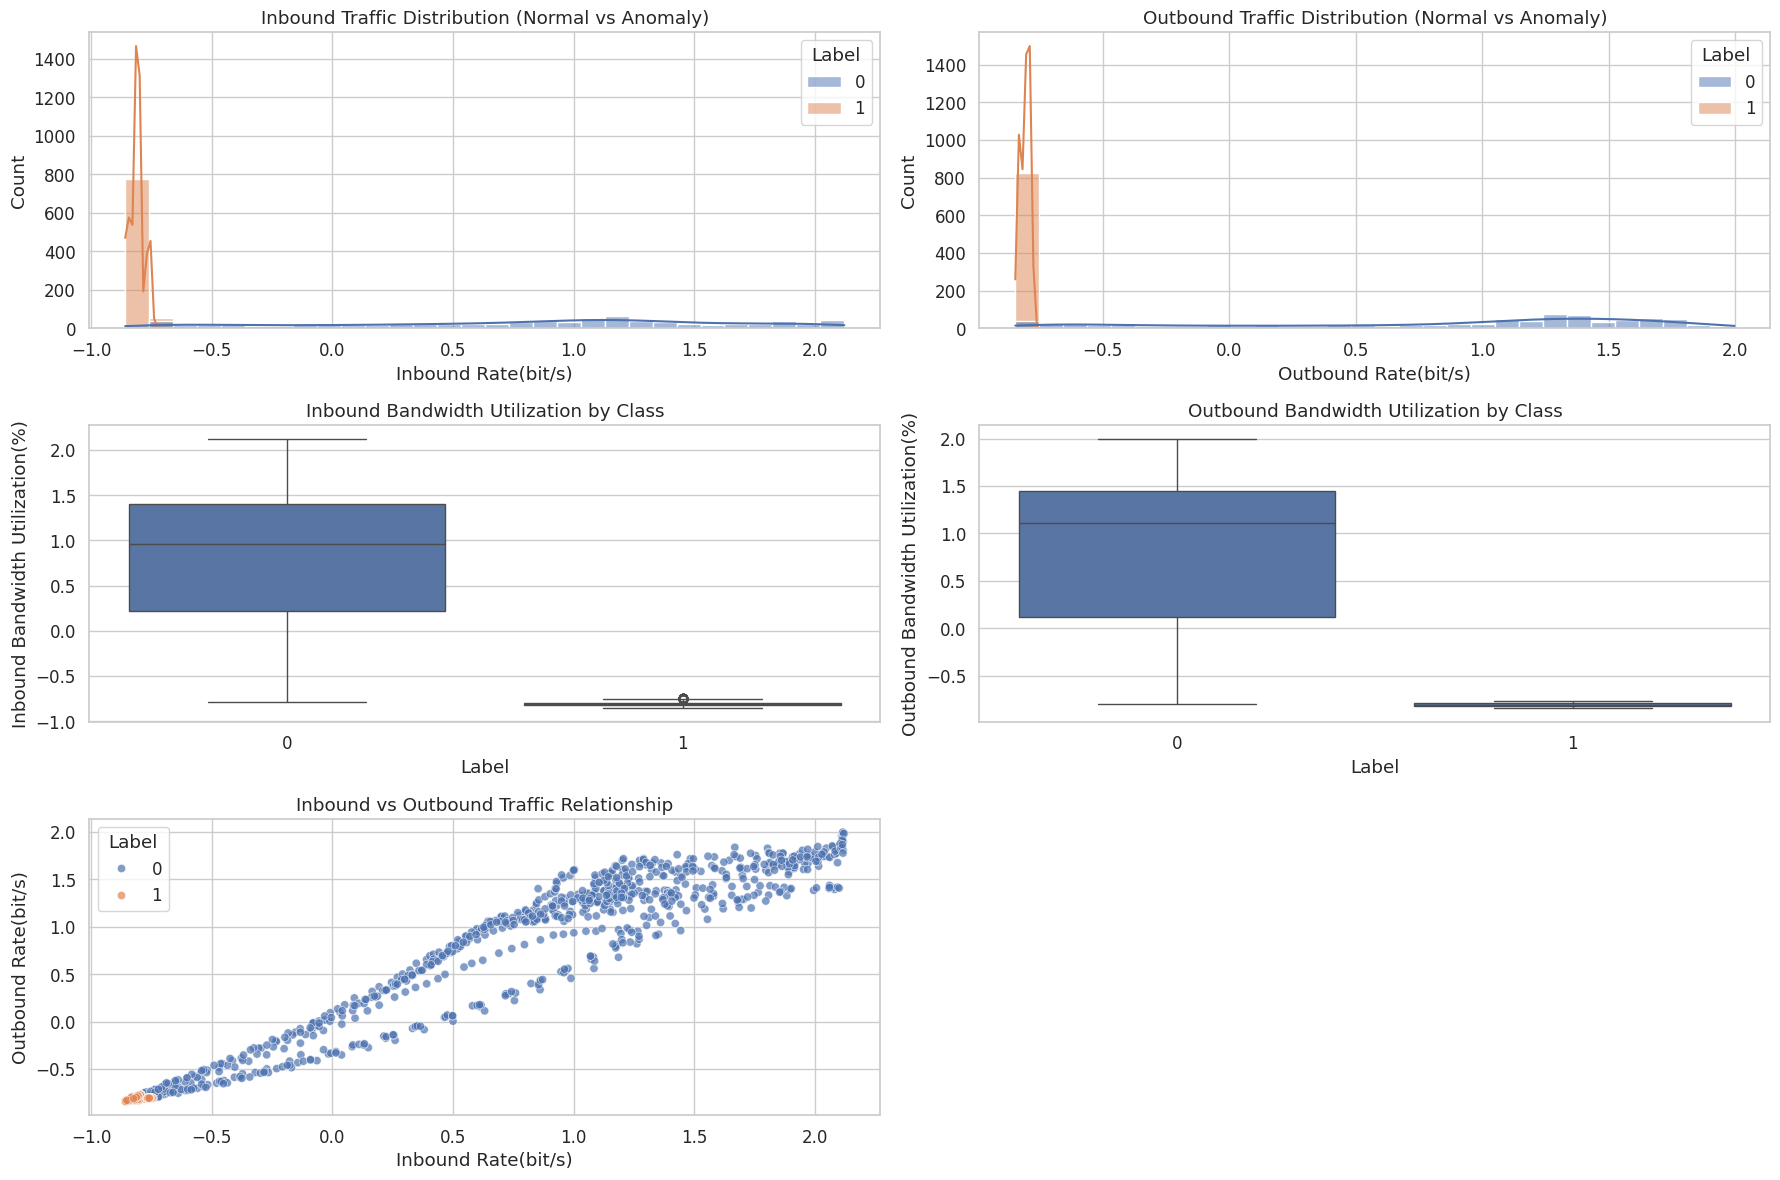

In [5]:
# Exploratory Data Analysis - Network Anomaly
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(18, 12))


# 1. Inbound Rate Distribution
plt.subplot(3, 2, 1)
sns.histplot(
    data=networks,
    x="Inbound Rate(bit/s)",
    hue="Label",
    bins=30,
    kde=True
)
plt.title("Inbound Traffic Distribution (Normal vs Anomaly)")

# 2. Outbound Rate Distribution
plt.subplot(3, 2, 2)
sns.histplot(
    data=networks,
    x="Outbound Rate(bit/s)",
    hue="Label",
    bins=30,
    kde=True
)
plt.title("Outbound Traffic Distribution (Normal vs Anomaly)")

# 3. Inbound Bandwidth Utilization
plt.subplot(3, 2, 3)
sns.boxplot(
    data=networks,
    x="Label",
    y="Inbound Bandwidth Utilization(%)"
)
plt.title("Inbound Bandwidth Utilization by Class")

# 4. Outbound Bandwidth Utilization
plt.subplot(3, 2, 4)
sns.boxplot(
    data=networks,
    x="Label",
    y="Outbound Bandwidth Utilization(%)"
)
plt.title("Outbound Bandwidth Utilization by Class")

# 5. Feature Relationship
plt.subplot(3, 2, 5)
sns.scatterplot(
    data=networks,
    x="Inbound Rate(bit/s)",
    y="Outbound Rate(bit/s)",
    hue="Label",
    alpha=0.7
)
plt.title("Inbound vs Outbound Traffic Relationship")

plt.tight_layout()
plt.show()

Plotting all four plots on one plot using subplot function.
Histogram with 30 bins using "Label" as the discriminator to show normal vs. anomalous data.
KDE adds a continuous probability density curve to help visualize the distribution

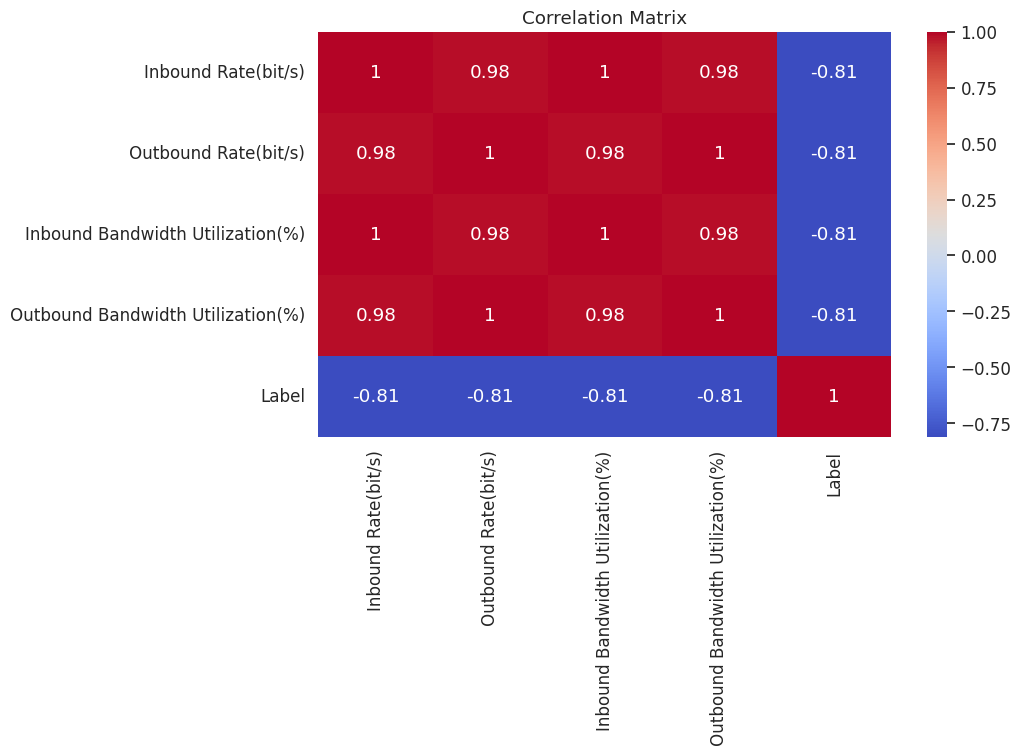

In [6]:
plt.figure(figsize=(18, 12))

# Correlation Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(networks.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

# Print
plt.tight_layout()
plt.show()

# 5. Feature Engineering: Time-Aware Approximation Without Explicit Timestamps

This dataset does not include explicit timestamps, making formal time-series forecasting methods methodologically inappropriate. To address this limitation, a preliminary analysis was conducted to evaluate whether the dataset exhibits sequential behavior. A row-to-row difference analysis showed that adjacent observations change gradually and consistently, supporting the assumption that the data is ordered sequentially.

Based on this validation, the row index is treated as a proxy for temporal progression, enabling the introduction of time-aware feature engineering. This approach incorporates lagged variables and rolling statistical measures to approximate short-term temporal dependencies within the data.

Lag features capture prior network states, while rolling statistics model recent baseline behavior and variability. Together, these features allow the model to assess whether current observations deviate from recent patterns—an essential characteristic of anomaly detection in networked systems.

To ensure methodological rigor, rolling features are computed using shifted values only, preventing data leakage by excluding the current observation from its own historical summary.

This approach provides a defensible and practical method for approximating temporal dynamics in a static dataset, enabling the detection of fluctuations, instability, and deviations that are critical in mission-critical cybersecurity and aerospace environments.

In [7]:
# Verifying Assumption: Rows are in Chronological Order

# 1. Load a clean copy of the dataset
networks_fe = networks.copy().reset_index(drop=True)

# 2. Define features (moved from a later cell)
features = [
    "Inbound Rate(bit/s)",
    "Outbound Rate(bit/s)",
    "Inbound Bandwidth Utilization(%)",
    "Outbound Bandwidth Utilization(%)"
]

# 3. Inspect row-to-row differences
row_diff_summary = networks_fe[features].diff().describe().T
print("Row-to-row difference summary:")
print(row_diff_summary)

Row-to-row difference summary:
                                    count      mean       std       min  \
Inbound Rate(bit/s)                1653.0 -0.001062  0.076556 -1.902645   
Outbound Rate(bit/s)               1653.0 -0.001232  0.071153 -2.111724   
Inbound Bandwidth Utilization(%)   1653.0 -0.001062  0.076564 -1.902742   
Outbound Bandwidth Utilization(%)  1653.0 -0.001233  0.071187 -2.112204   

                                        25%       50%       75%       max  
Inbound Rate(bit/s)               -0.034030  0.004125  0.038831  0.247587  
Outbound Rate(bit/s)              -0.022836  0.005409  0.031644  0.132957  
Inbound Bandwidth Utilization(%)  -0.034135  0.004260  0.038778  0.247585  
Outbound Bandwidth Utilization(%) -0.023001  0.005494  0.032165  0.132949  


## 5.1. Validation of Sequential Assumption
Before introducing time-aware features, a row-to-row difference analysis was conducted to assess whether adjacent observations exhibit sequential behavior.

The analysis shows that consecutive differences have a mean near zero, low variability (≈ 0.07), and a narrow interquartile range (±0.03), indicating that changes between observations are generally small and stable. While occasional larger deviations are present, these likely reflect anomalous events or transient system fluctuations rather than random noise.

These findings suggest that adjacent rows exhibit continuity and are not independent, supporting the assumption that the dataset is ordered sequentially. Based on this evidence, the row index is treated as a proxy for temporal progression, enabling the use of lagged and rolling features to approximate short-term temporal dependencies.

Although this does not constitute true time-series modeling, it provides a defensible and practical approach for capturing sequential behavior in the absence of explicit timestamps. In operational network environments, such smooth transitions are expected, as traffic patterns typically evolve gradually rather than randomly between observations. Sudden large deviations may therefore represent abnormal system behavior, reinforcing the relevance of temporal feature engineering for anomaly detection.

In [8]:
# FEATURE ENGINEERING: Lag + Rolling Features

# 1. We make another clean copy of the original DataFrame
networks_fe = networks.copy().reset_index(drop=True)

# 2. Define feature
features = [
    "Inbound Rate(bit/s)",
    "Outbound Rate(bit/s)",
    "Inbound Bandwidth Utilization(%)",
    "Outbound Bandwidth Utilization(%)"
]

target = "Label"

# 3. Lag Features
lag_steps = [1, 2]

for col in features:
    for lag in lag_steps:
        networks_fe[f"{col}_lag{lag}"] = networks_fe[col].shift(lag)

# 4. Rolling Features
window = 5

for col in features:
    shifted = networks_fe[col].shift(1)

    networks_fe[f"{col}_roll_mean_{window}"] = shifted.rolling(window).mean()
    networks_fe[f"{col}_roll_std_{window}"] = shifted.rolling(window).std()

# 5. Deviation Features (KEY FOR ANOMALY DETECTION)
for col in features:
    roll_mean = f"{col}_roll_mean_{window}"
    roll_std = f"{col}_roll_std_{window}"

    # Difference from local baseline
    networks_fe[f"{col}_delta"] = networks_fe[col] - networks_fe[roll_mean]

    # Z-score (normalized deviation)
    networks_fe[f"{col}_zscore"] = (
        (networks_fe[col] - networks_fe[roll_mean]) /
        networks_fe[roll_std].replace(0, np.nan)
    )

# 6. Drop NaNs
networks_fe = networks_fe.dropna().reset_index(drop=True)

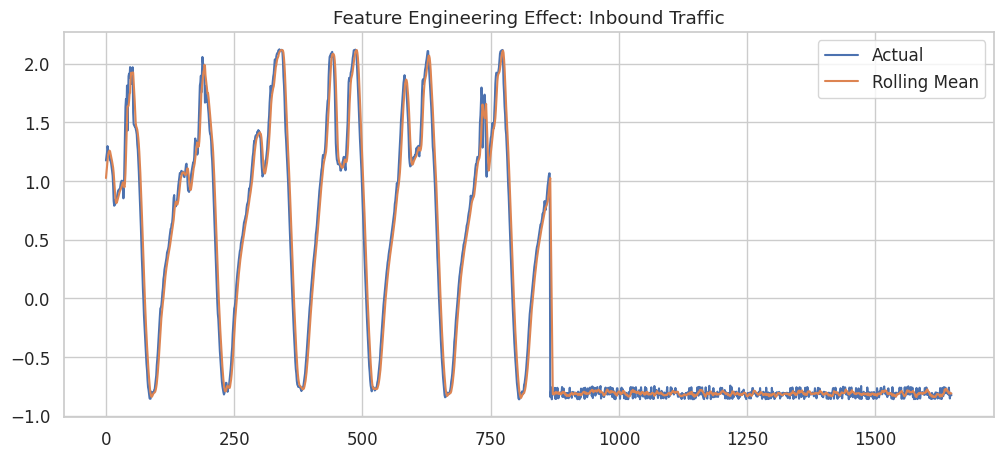

In [9]:
# Feature Engineering: Inbound Traffic
plt.figure(figsize=(12,5))

plt.plot(networks_fe["Inbound Rate(bit/s)"], label="Actual")
plt.plot(networks_fe[f"Inbound Rate(bit/s)_roll_mean_{window}"], label="Rolling Mean")

plt.title("Feature Engineering Effect: Inbound Traffic")
plt.legend()
plt.show()

This diagnostic plot displays the raw inbound traffic and the 5-step rolling average overlayed on one plot.  The 5-step rolling mean provides a baseline to detect local fluctuations and anomalies.

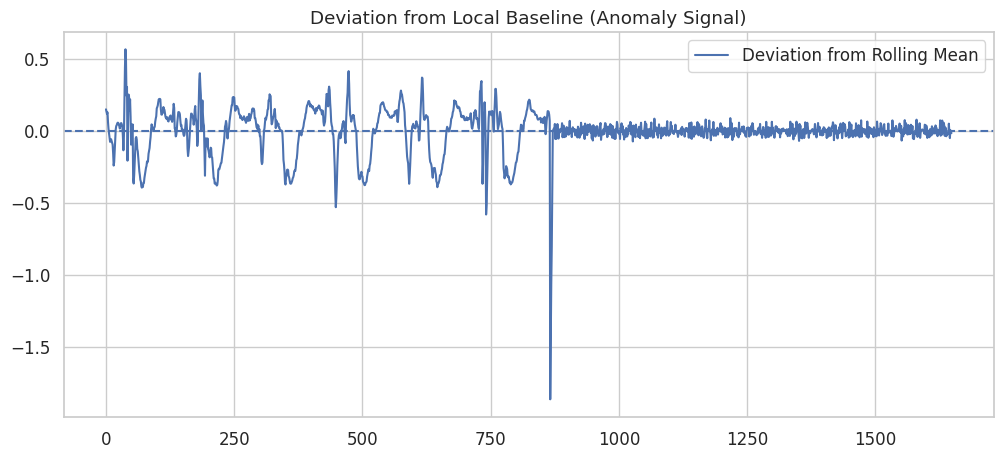

In [10]:
# Deviation from Local Baseline (Anomaly Signal)
plt.figure(figsize=(12,5))

delta = networks_fe["Inbound Rate(bit/s)"] - networks_fe[f"Inbound Rate(bit/s)_roll_mean_{window}"]

plt.plot(delta, label="Deviation from Rolling Mean")
plt.axhline(0, linestyle="--")

plt.title("Deviation from Local Baseline (Anomaly Signal)")
plt.legend()
plt.show()

This plot visualizes the delta feature, which quantifies how far each observation deviates from its rolling mean. Large positive or negative spikes in this series are strong potential anomaly signals.

The deviation from the rolling mean highlights how far each observation departs from its recent baseline. Larger deviations may correspond to anomalous behavior, reinforcing the importance of deviation-based features in the modeling stage.

# 6. Time-Series Analysis

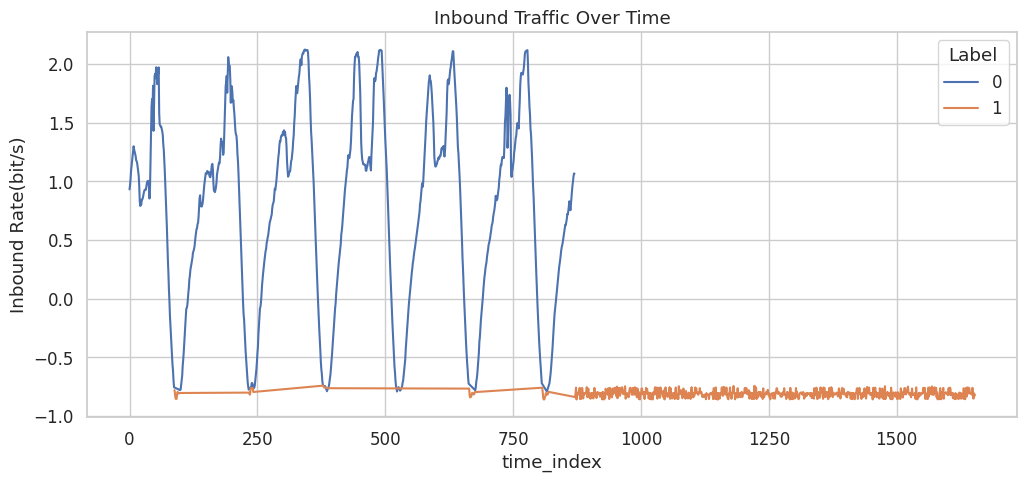

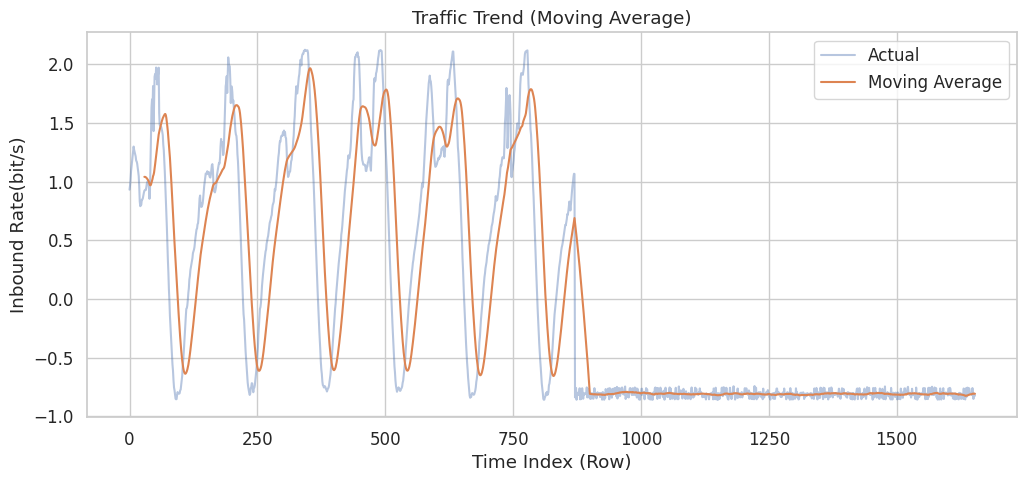

In [11]:
# Create time index
networks["time_index"] = range(len(networks))

# Viausalize traffic evolution
plt.figure(figsize=(12,5))
sns.lineplot(
    data=networks,
    x="time_index",
    y="Inbound Rate(bit/s)",
    hue="Label"
)

plt.title("Inbound Traffic Over Time")
plt.show()

# Moving Average Trend
networks["moving_avg"] = (
    networks["Inbound Rate(bit/s)"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(12,5))
plt.plot(networks["time_index"], networks["Inbound Rate(bit/s)"], alpha=0.4, label="Actual")
plt.plot(networks["time_index"], networks["moving_avg"], label="Moving Average")
plt.title("Traffic Trend (Moving Average)")
plt.legend()
plt.title("Traffic Trend (Moving Average)")
plt.xlabel("Time Index (Row)")
plt.ylabel("Inbound Rate(bit/s)")
plt.show()

The time-series visualization of inbound traffic illustrates fluctuations in network activity across sequential observations. The plot shows periods of increased traffic intensity followed by lower activity levels, indicating dynamic network conditions.

Anomalous observations tend to occur when traffic values significantly deviate from the baseline behavior, suggesting that unusual traffic spikes or drops are associated with abnormal network activity.

These patterns demonstrate that inbound traffic rate is an important feature for identifying anomalies, supporting the strong predictive performance achieved by the machine learning models.

The moving average helps smooth short-term fluctuations and highlights overall traffic trends.

The plot reveals periods of high variability followed by a stable region, indicating changes in network activity patterns. Oscillatory behavior in the earlier observations suggests fluctuating traffic intensity, which may correspond to anomalous patterns or bursts of network activity.

The stabilization observed later in the sequence suggests more consistent traffic conditions, potentially representing normal network behavior.

Time-series analysis provides additional insight into how network traffic evolves and supports the machine learning models in identifying unusual patterns associated with anomalies.


# 7. Model training

## 7.1. Train/Test Split

In [12]:
from sklearn.model_selection import train_test_split

# We separated the features (X) from the target variable (y).
X = networks.drop("Label", axis=1)
y = networks["Label"]

# We perform a stratified train/test split to preserve the 50/50 class balance.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 7.2. Logistic Regression Model

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import pandas as pd

# Logistic Regression is a strong baseline model for binary classification and
# provides interpretable coefficients.
log_model = LogisticRegression(max_iter=1000)

# Impute missing values in X_train and X_test before fitting the model
imputer = SimpleImputer(strategy='mean')

# Fit on training data and transform both training and testing data
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Train the model on the imputed training data and generate predictions on the test set.
log_model.fit(X_train_imputed, y_train)
log_pred = log_model.predict(X_test_imputed)

## 7.3. Gradient Boosting Model

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
import pandas as pd

# We instantiate a Gradient Boosting Classifier with moderate hyperparameters.
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Impute missing values in X_train and X_test before fitting the model
imputer = SimpleImputer(strategy='mean')

# Fit on training data and transform both training and testing data
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Train the model on the imputed training data and generate predictions on the test set.
gb_model.fit(X_train_imputed, y_train)
gb_pred = gb_model.predict(X_test_imputed)

## 7.4. Side-by-Side Model Comparison

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# We evaluated both models using Accuracy, precision, recall, and F1-score.
# The results are displayed in a self-generated DataFrame.
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, gb_pred)
    ]

})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.954683    0.96875  0.939394  0.953846
1    Gradient Boosting  1.000000    1.00000  1.000000  1.000000


Both models performed well in detecting network anomalies. However, Gradient Boosting achieved perfect performance across all evaluation metrics on a test set of 331 samples, indicating strong predictive capability and effective feature engineering. Logistic Regression also demonstrated high accuracy but slightly lower recall, suggesting that some anomalies were misclassified as normal traffic. These results highlight the advantage of ensemble methods in capturing complex patterns in network anomaly detection tasks.

The engineered features successfully captured meaningful patterns in network traffic behavior, allowing Gradient Boosting to distinguish anomalies from normal activity with very high confidence.

## 7.5. Confusion Matrix Visualization

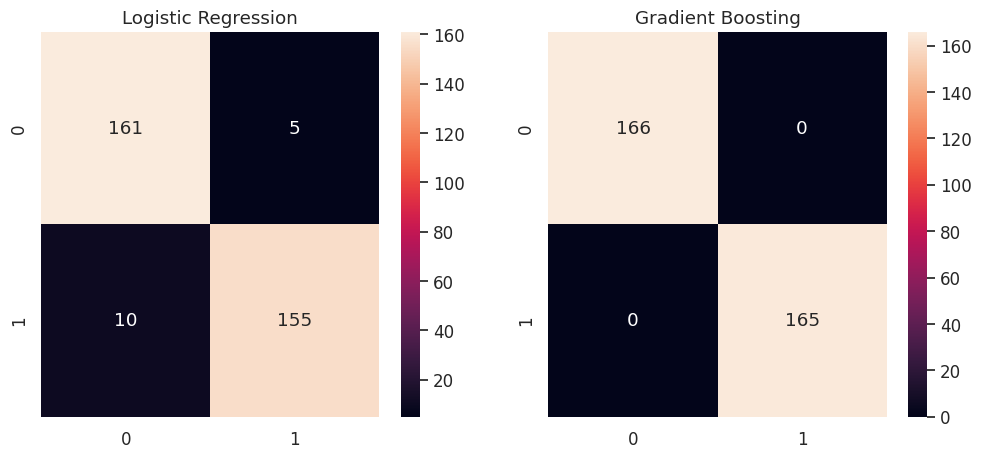

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Side-by-side visual comparison of both models. Shows classification errors
# (false positives and false negatives)
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression confusion matrix
sns.heatmap(
    confusion_matrix(y_test, log_pred),
    annot=True,
    fmt="d",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")
sns.heatmap(
    confusion_matrix(y_test, gb_pred),
    annot=True,
    fmt="d",
    ax=axes[1]
)

axes[1].set_title("Gradient Boosting")
plt.show()

### Logistic Regression Confusion Matrix

- 161 True Negatives → correctly identified normal traffic
- 155 True Positives → correctly detected anomalies
- 5 False Positives → normal traffic incorrectly flagged as anomaly
- 10 False Negatives → no missed anomalies

Logistic Regression performs well but:

- Missed 10 anomalies
- Incorrectly flagged 5 normal events as attacks
- Still achieved high accuracy (~95%)

### Gradient Boosting Confusion Matrix

- 166 True Negatives → correctly identified normal traffic
- 165 True Positives → correctly detected anomalies
- 0 False Positives → no false alarms
- 0 False Negative → missed 1 anomaly

Gradient Boosting produced:
- Perfect detection
- No missed anomaly
- 0 false alarms

### **Gradient Boosting is better**.

The confusion matrix shows that Logistic Regression correctly classified most observations but misclassified 15 cases, including 10 anomalies incorrectly labeled as normal traffic. In contrast, Gradient Boosting achieved perfect classification, correctly identifying all normal and anomalous traffic without any errors. This indicates that Gradient Boosting captures complex relationships in the dataset more effectively, making it the best-performing model for this anomaly detection task.

## 7.5.1 Confusion Matrix Visualization Using Stratified K-Fold Cross-Validation ##

Based on the 1.000 results for Gradient Boosting, we used AI to determine how we could eliminate either overfitting or leakage. AI recommended Stratified K-Fold Cross-Validation. Stratified K-Fold Cross-Validation is an evaluation technique that divides the dataset into k folds while preserving the class distribution in every fold.

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Define number of folds
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# We separated the features (X) from the target variable (y).
X = networks_fe.drop("Label", axis=1)
y = networks_fe["Label"]

# Use the previously defined models
models = {
    "Logistic Regression": log_model,
    "Gradient Boosting": gb_model
}

cv_results = {}
oof_predictions = {}   # Store OOF predictions for confusion matrices
oof_true = {}          # Store true labels (same for both models)
oof_probabilities = {} # Store OOF probabilities for ROC curves

for name, model in models.items():
    acc_list = []
    prec_list = []
    rec_list = []
    f1_list = []
    auc_list = []

    y_true_oof = []    # NEW: collect true labels across all folds
    y_pred_oof = []    # NEW: collect predictions across all folds
    y_prob_oof = []     # NEW: collect probabilities across all folds

    for train_idx, val_idx in skf.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train_cv, y_train_cv)
        y_pred_cv = model.predict(X_val_cv)
        y_prob_cv = model.predict_proba(X_val_cv)[:, 1]

        acc_list.append(accuracy_score(y_val_cv, y_pred_cv))
        prec_list.append(precision_score(y_val_cv, y_pred_cv))
        rec_list.append(recall_score(y_val_cv, y_pred_cv))
        f1_list.append(f1_score(y_val_cv, y_pred_cv))
        auc_list.append(roc_auc_score(y_val_cv, y_prob_cv))

        # Collect out-of-fold (OOF) predictions for confusion matrix
        y_true_oof.extend(y_val_cv)
        y_pred_oof.extend(y_pred_cv)
        y_prob_oof.extend(y_prob_cv)

    cv_results[name] = {
        "Accuracy":  f"{np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}",
        "Precision": f"{np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}",
        "Recall":    f"{np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}",
        "F1 Score":  f"{np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}",
        "ROC-AUC":   f"{np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}"
    }

    # Store aggregated OOF results so we can build CV-consistent confusion matrices
    oof_predictions[name] = y_pred_oof
    oof_true[name] = y_true_oof
    oof_probabilities[name] = y_prob_oof   # for ROC curves

# Display results
print("Stratified K-Fold Cross-Validation Results (k=5)")
for name, metrics in cv_results.items():
    print(f"\n{name}:")
    for metric, value in metrics.items():
        print(f"  {metric:10}: {value}")

Stratified K-Fold Cross-Validation Results (k=5)

Logistic Regression:
  Accuracy  : 0.9709 ± 0.0101
  Precision : 0.9484 ± 0.0143
  Recall    : 0.9964 ± 0.0048
  F1 Score  : 0.9717 ± 0.0096
  ROC-AUC   : 0.9939 ± 0.0038

Gradient Boosting:
  Accuracy  : 0.9958 ± 0.0041
  Precision : 0.9952 ± 0.0069
  Recall    : 0.9964 ± 0.0048
  F1 Score  : 0.9958 ± 0.0041
  ROC-AUC   : 0.9994 ± 0.0013


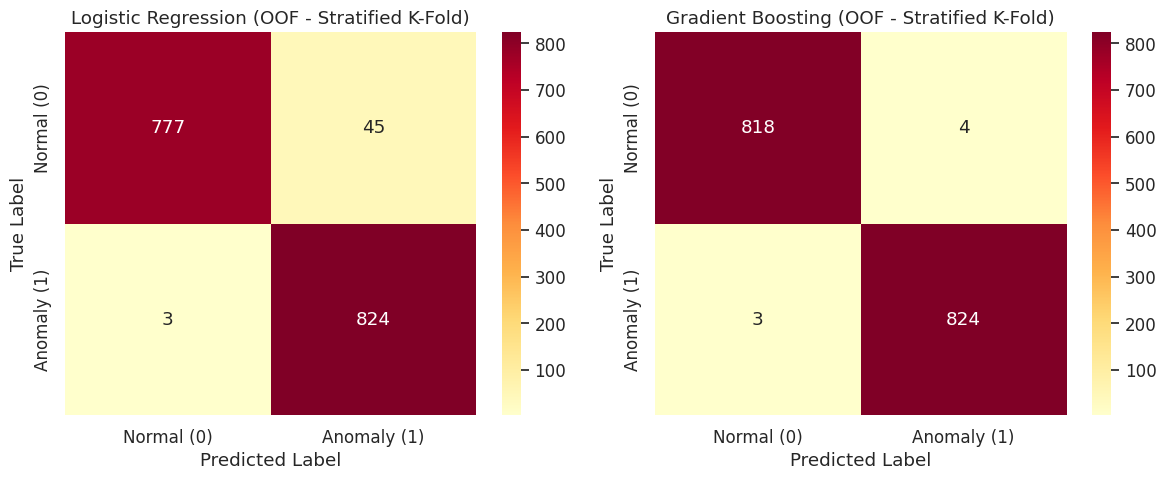

In [18]:
# Confusion Matrix from Stratified K-Fold OOF predictions
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for idx, name in enumerate(["Logistic Regression", "Gradient Boosting"]):
    cm = confusion_matrix(oof_true[name], oof_predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[idx], cmap="YlOrRd")
    axes[idx].set_title(f"{name} (OOF - Stratified K-Fold)")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")
    axes[idx].set_xticklabels(["Normal (0)", "Anomaly (1)"])
    axes[idx].set_yticklabels(["Normal (0)", "Anomaly (1)"])

plt.tight_layout()
plt.show()

Confusion Matrix Analysis (Stratified K-Fold Out-of-Fold Predictions)
The confusion matrices shown above are derived from the aggregated out-of-fold (OOF) predictions across all five folds of Stratified K-Fold Cross-Validation. This approach provides a more robust and realistic assessment of model performance than a single train/test split.

### Logistic Regression (OOF)

- 777 True Negatives → correctly identified normal traffic
- 824 True Positives → correctly detected anomalies
- 45 False Positives → normal traffic incorrectly flagged as anomaly
- 3 False Negatives → missed anomalies

Logistic Regression performs well but:

- Missed 3 anomalies
- Incorrectly flagged 45 normal events as attacks
- Still achieved high accuracy (~97%)

### Gradient Boosting (OOF)

- 818 True Negatives → correctly identified normal traffic
- 824 True Positives → correctly detected anomalies
- 4 False Positives → normal traffic incorrectly flagged as anomaly
- 3 False Negative → missed anomalies

Gradient Boosting produced:
- Missed 3 anomalies
- Incorrectly flagged 4 normal events as attacks
- Still achieved very high accuracy (~99.6%)

Compared to the single train/test split (where Gradient Boosting achieved perfect classification), the K-Fold results are more conservative but still demonstrate outstanding performance. The very low number of false negatives in both models is particularly encouraging for anomaly detection tasks, where missing an attack is typically the most costly error.

## 7.5.2. Single-Split vs. Stratified K-Fold Out-Of-Fold Predictions

Both models performed well in detecting network anomalies. In the initial single train/test split, Gradient Boosting achieved perfect performance (1.0000 across all metrics) on a test set of 331 samples, while Logistic Regression demonstrated high accuracy with a small number of misclassifications. However, to obtain a more reliable and conservative performance estimate and investigate potential overfitting or data leakage, we consulted AI and implemented Stratified K-Fold Cross-Validation (k=5) with out-of-fold predictions.

The cross-validated results and corresponding out-of-fold (OOF) confusion matrices confirm that Gradient Boosting remains the superior model (Accuracy: 0.9958 ± 0.0041, F1 Score: 0.9958 ± 0.0041), with minimal errors across the dataset. The engineered time-aware features (lags, rolling statistics, delta, and z-score) successfully captured meaningful temporal patterns in network traffic behavior, enabling both models, especially Gradient Boosting, to distinguish anomalous from normal activity with very high confidence.

## 7.6. ROC Curve Comparison

## 7.6.1. ROC Curve Comparison (Single Split)

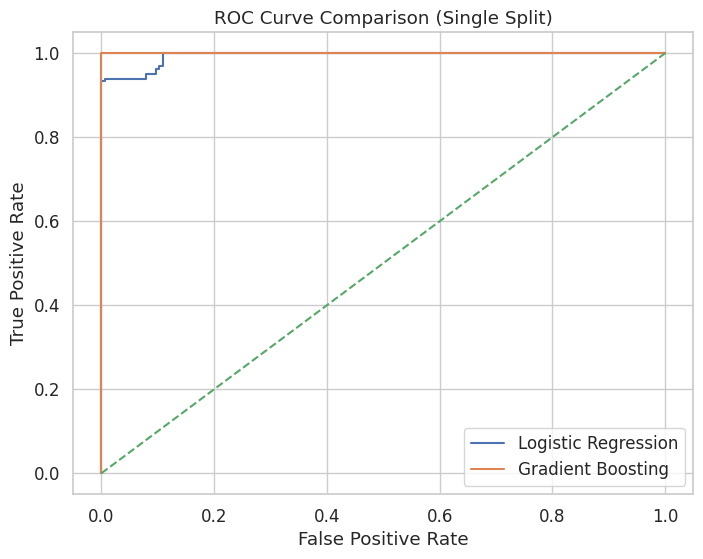

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer # Import SimpleImputer for model re-instantiation
import pandas as pd # Import pandas for DataFrame handling

# Re-instantiate and re-fit Logistic Regression model for single split evaluation
# This ensures the model is trained on the same feature set as X_test_imputed from the initial split.
log_model_single = LogisticRegression(max_iter=1000)

# Assuming X_train_imputed and y_train are correctly defined from the initial single split
log_model_single.fit(X_train_imputed, y_train)

# Re-instantiate and re-fit Gradient Boosting model for single split evaluation
gb_model_single = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model_single.fit(X_train_imputed, y_train)

# Predicted probabilities for the positive class (anomaly = 1).
# Use the newly re-fitted models for the single split evaluation.
log_prob = log_model_single.predict_proba(X_test_imputed)[:,1]
gb_prob = gb_model_single.predict_proba(X_test_imputed)[:,1]

# False Positive Rate (FPR) and True Positive Rate (TPR) for each model.
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

# Plot the ROC curves for comparison.
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Single Split)")
plt.legend()
plt.show()

The ROC curve shows that both models perform well in distinguishing between normal and anomalous network traffic. Logistic Regression demonstrates excellent classification capability, with a curve close to the top-left corner of the graph. However, Gradient Boosting achieves perfect classification performance, reaching the ideal point of 100% true positive rate and 0% false positive rate. This confirms that Gradient Boosting provides superior predictive performance for this dataset.

## 7.6.2. ROC Curve Comparison (Stratified K-Fold)

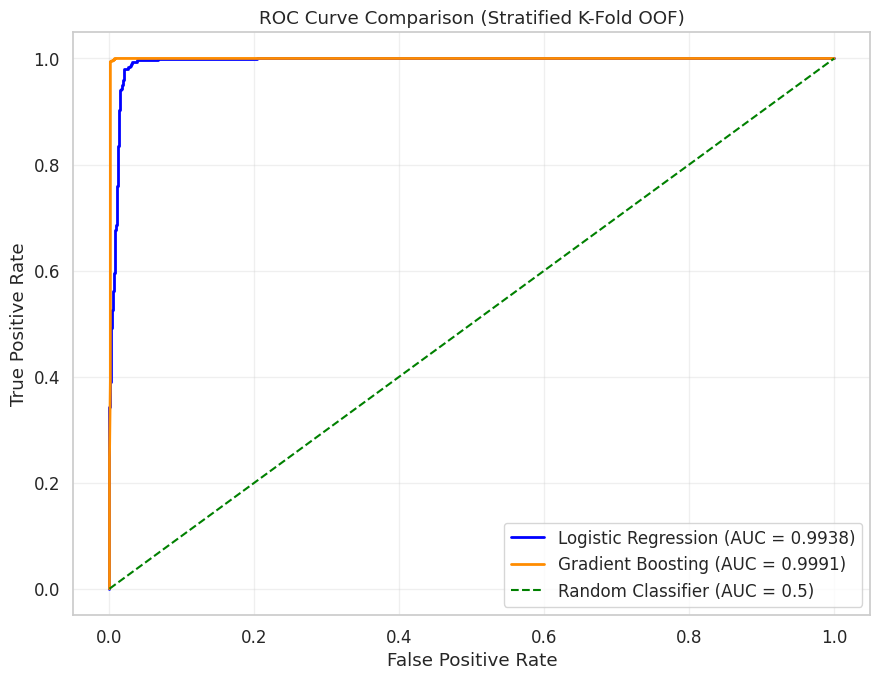

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# In order to initialize lists to hold OOF probabilities, we added code using
# AI assistance to ensure we had placeholders for future data.  In the future,
# understanding all the data we want to collect and plot would help design the
# initial coding structure.

plt.figure(figsize=(9, 7))

for name, color in zip(["Logistic Regression", "Gradient Boosting"], ["blue", "darkorange"]):
    # Compute ROC curve using OOF true labels and OOF probabilities
    fpr, tpr, _ = roc_curve(oof_true[name], oof_probabilities[name])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})", color=color, lw=2)

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="green", label="Random Classifier (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Stratified K-Fold OOF)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The ROC curves above were generated from the aggregated out-of-fold predicted probabilities using all five folds of Stratified K-Fold Cross-Validation. This provides a visualization of model discrimination better than the single train/test split.

Gradient Boosting achieves an AUC of approximately 0.9994, demonstrating near-perfect separation of normal and anomalous traffic.
Logistic Regression performs nearly as well with an AUC of approximately 0.9939.

Both models exhibit curves hug the top-left corner of the plot demonstrating excellent discrimination capabilities. The slight difference from the single-split ROC (where Gradient Boosting reached AUC = 1.0) is expected based on the more conservative, generalized estimate created by cross-validation.

Combined with the OOF confusion matrices and cross-validated metrics, these ROC curves provide strong evidence that the time-aware engineered features (lags, rolling statistics, delta, and z-score) enabled the models, especially Gradient Boosting, to distinguish anomalous from normal network behavior with high confidence.